## Experiment Workflow Test
Short notebook to validate the new experiment file workflow (`experiments/podmr.py` and `experiments/rabi.py`).

In [9]:
# Adjust if your VS Code kernel needs help finding pip / scripts
import os
python_path = r"C:\Users\QT3 User Facility\AppData\Local\Programs\Python\Python314\Scripts"
os.environ["PATH"] = python_path + ";" + os.environ["PATH"]

!pip show qickdawg

Name: qickdawg
Version: 1.2.1
Summary: Software for full quantum control of nitrogen-vacancy defects and other quantum defects in diamond
Home-page: 
Author: 
Author-email: Andy Mounce <amounce@sandia.gov>, Emmeline Riendeau <eriendeau@uchicago.edu>
License: MIT License 

Copyright 2023 National Technology & Engineering Solutions of Sandia, LLC (NTESS). Under the terms of Contract DE-NA0003525 with NTESS, the U.S. Government retains certain rights in this software.

Permission is hereby granted, free of charge, to any person obtaining a copy of this software and associated documentation files (the "Software"), to deal in the Software without restriction, including without limitation the rights to use, copy, modify, merge, publish, distribute, sublicense, and/or sell copies of the Software, and to permit persons to whom the Software is furnished to do so, subject to the following conditions:

The above copyright notice and this permission notice shall be included in all copies or substa

In [10]:
%load_ext autoreload
%autoreload 2

import sys
import numpy as np
import matplotlib.pyplot as plt
from copy import copy
from scipy.optimize import curve_fit
import qickdawg as qd
from importlib.metadata import version

print(f"numpy     {version('numpy')}")
print(f"qickdawg  {version('qickdawg')}")
print(f"python    {sys.version}")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
numpy     2.3.3
qickdawg  1.2.1
python    3.14.0 (tags/v3.14.0:ebf955d, Oct  7 2025, 10:15:03) [MSC v.1944 64 bit (AMD64)]


### Connect to board

In [11]:
qd.start_client('192.168.3.1')
print("Connected — soccfg loaded:", qd.soccfg is not None)

Connected — soccfg loaded: True


### Laser on / off check

In [ ]:
default_config = qd.NVConfiguration()

default_config.adc_channel              = 0
default_config.mw_channel               = 0
default_config.mw_nqz                   = 1
default_config.mw_gain                  = 1800
default_config.laser_gate_pmod          = 0
default_config.laser_on_tus             = 2
default_config.laser_readout_offset_tus = 1.172
default_config.readout_integration_tns  = 300
default_config.mw_laser_delay_treg      = 0
default_config.relax_delay_tus          = 1.1
default_config.pre_init                 = True

# Expected: laser should illuminate the sample
qd.laser_on(copy.copy(default_config))

0.3284313725490196

In [ ]:
# Expected: laser should turn off
qd.laser_off(copy.copy(default_config))

4.9411764705882355

### PL counts — live scope

In [15]:
config = copy(default_config)
config.readout_integration_treg = 2**16 - 1
config.reps = 1

prog = qd.PLIntensity(config)

def get_cps():
    d = prog.acquire(progress=False)
    return d / qd.max_int_time_treg / qd.min_time_tns * 1e9

# qd.live_plot(get_cps)

### Run PODMR experiment script
Edit parameters in `experiments/podmr.py` (EXPERIMENT PARAMETERS block), then run this cell.
The script handles connection, sweep config, acquisition, HDF5 save, and plot internally.
Use `%run -i` to inject variable overrides from a prior cell without editing the file.

[config] Warning: calibration.pi_pulse_tns is not set.
[config] Warning: calibration.pi2_pulse_tns is not set.
[config] Connecting to QICK at 192.168.3.1 ...
[config] Connected.

Requested 1840.0 to 1850.0 by 0.1
Instead using 1839.9999996185302 to 1849.9999614715575 by 0.09999961853027343 in 101 steps
[podmr] MW duration: 650 ns (calibration.lower_dip.pi_pulse_tns) → 3195 tdds samples
[podmr] Active transition: lower_dip | freq=1845.7400001525878 MHz | gain=1800


100%|██████████| 10100000/10100000 [01:18<00:00, 128080.34it/s]


[podmr] Saved → c:\Users\QT3 User Facility\Documents\qick-dawg\data\podmr\podmr_20260318_134524.h5
[podmr] Dip frequency (fit): 1838.320071 MHz


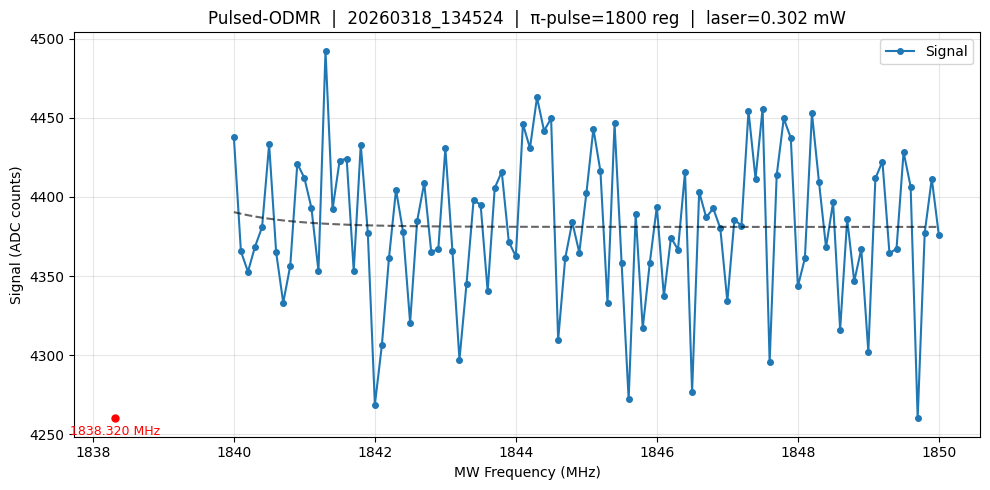

[podmr] Plot saved → c:\Users\QT3 User Facility\Documents\qick-dawg\data\podmr\podmr_20260318_134524.png


In [16]:
import sys, os
sys.path.insert(0, os.path.abspath("../experiments"))

%run ../experiments/podmr.py

#### Quick inline PODMR re-plot
`%run` leaves `data`, `config`, `x_mhz`, and `timestamp` in the kernel namespace.
Re-plot here without re-acquiring to iterate on visuals.

NameError: name 'x_mhz' is not defined

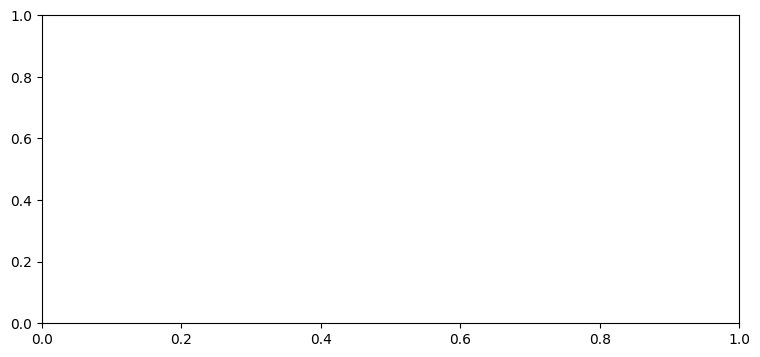

In [8]:
# ratio plot — works whether data is (nsweep,) or (2, nsweep)
if data.ndim == 2 and data.shape[0] == 2:
    ratio = data[0] / data[1]
else:
    ratio = data

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(x_mhz, ratio, marker="o", markersize=3, linewidth=1.2)
ax.set_xlabel("MW Frequency (MHz)")
ax.set_ylabel("Contrast (ratio)")
ax.set_title(f"pODMR quick view — {timestamp}")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Run Rabi experiment script
Edit parameters in `experiments/rabi.py`, then run this cell.

[config] Warning: calibration.pi_pulse_tns is not set.
[config] Warning: calibration.pi2_pulse_tns is not set.
[config] Connecting to QICK at 192.168.3.1 ...
[config] Connected.
[rabi] Sweep: 246 → 2458 tdds  (Δ 25)
[rabi] Active transition: lower_dip | freq=1845.7400001525878 MHz | gain=1800

Requested 246 to 2458 by 25
Instead using 246 to 2471 by 25 in 89


100%|██████████| 89/89 [00:00<00:00, 12648.86it/s]

[rabi] Saved → c:\Users\QT3 User Facility\Documents\qick-dawg\data\rabi\rabi_20260318_120504.h5


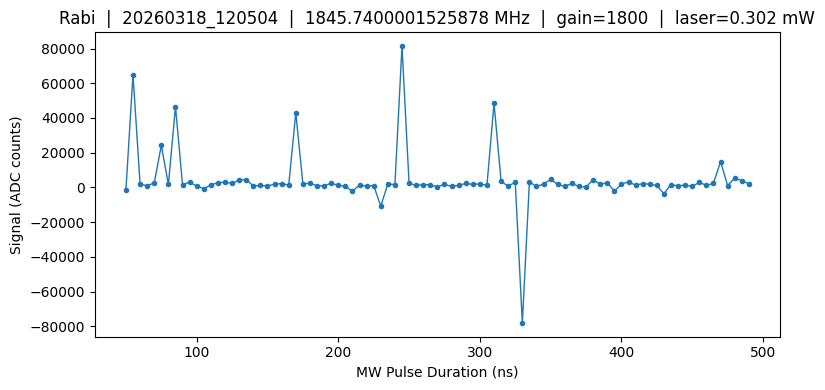

[rabi] Plot saved → c:\Users\QT3 User Facility\Documents\qick-dawg\data\rabi\rabi_20260318_120504.png


In [ ]:
%run ../experiments/rabi.py

#### Quick inline Rabi re-plot
`%run` leaves `data`, `config`, `x_ns`, and `timestamp` in the kernel namespace.

NameError: name 'x_ns' is not defined

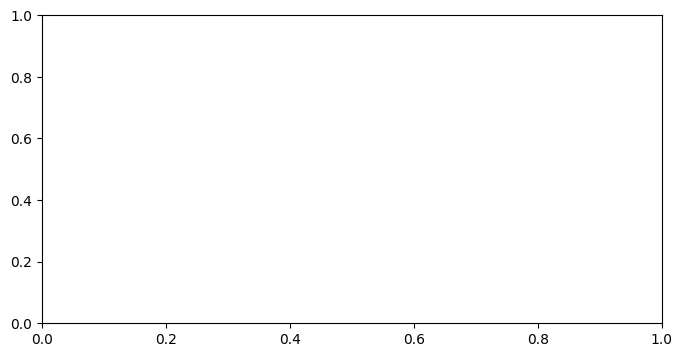

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(x_ns, data, marker="o", markersize=3, linewidth=1.2)
ax.set_xlabel("MW Pulse Duration (ns)")
ax.set_ylabel("Signal (ADC counts)")
ax.set_title(f"Rabi quick view — {timestamp}")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Save PODMR result to CSV (workflow verification)

In [ ]:
import pandas as pd
from pathlib import Path

csv_dir = Path("../data/podmr")
csv_dir.mkdir(parents=True, exist_ok=True)

if data.ndim == 2 and data.shape[0] == 2:
    sig, ref = data[0], data[1]
else:
    sig, ref = data, np.ones_like(data)

df = pd.DataFrame({
    "frequency_MHz": x_mhz,
    "signal":        sig,
    "reference":     ref,
    "ratio":         sig / ref,
})

csv_path = csv_dir / f"podmr_workflow_test_{timestamp}.csv"
df.to_csv(csv_path, index=False)
print(f"Saved → {csv_path.resolve()}")